# DiffDock 虚拟筛选教程

对应书稿章节：3.2.2 半柔性对接（基于分子变换的路线）。
教学数据：使用 `demo_data/CoreSet.dat` 中的 20 个代表性复合物子集，不等同于完整 CASF-2016 core set。

本 notebook 只保留 **全局 translation / rotation / torsion 去噪** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, describe_model_parameters,
    history_frame, load_complex, metric_frame, parse_pdb_ids,
    plot_loss_curves, compute_rmsd, SinusoidalEmbedding,
)
from teaching_demos.common import so3, torus
from teaching_demos.common import (
    Channel,
    randomize_position_3way,
    axis_angle_to_matrix,
    get_rotatable_bonds,
    manifold_score_loss,
    modify_torsion_angles,
    reverse_diffusion_loop,
    t_to_sigma_3way,
)


## 1. 超参数设置

DiffDock 的超参数分为两大类：

### 模型与训练参数
- `DISTANCE_CUTOFF`：蛋白-配体交互距离阈值，决定哪些原子对之间构建消息传递边
- `HIDDEN_DIM`：隐层维度，控制模型容量
- `N_EPOCHS`：训练轮数
- `LR`：学习率，扩散模型通常使用较小的学习率以保证训练稳定性

### 噪声调度参数（DiffDock 特有）
三个通道使用不同的 sigma_min 和 sigma_max，因为平移、旋转、扭转的物理尺度和分布特性不同：
- **平移**: 以 Angstrom 为单位，范围较大 -> sigma in [0.1, 30.0]（对齐 raw DiffDock parsing.py:96 默认值）
- **旋转**: 以弧度为单位 -> sigma in [0.1, 1.65]（对齐 raw DiffDock parsing.py:94 默认值）
- **扭转**: 以弧度为单位，范围 [-pi, pi] -> sigma in [0.0314, 3.14]（对齐 raw DiffDock parsing.py:97-98，0.0314 ≈ π/100）

噪声调度公式（指数调度）：

    sigma(t) = sigma_min^(1-t) * sigma_max^t,  t in [0, 1]

> **教学版与原始 DiffDock 对齐说明**：
> 本教学版三通道 sigma 范围已与 raw DiffDock 默认值严格对齐：
> `tr_sigma ∈ [0.1, 30]`、`rot_sigma ∈ [0.1, 1.65]`、`tor_sigma ∈ [0.0314, 3.14]`。
> 这样可以保证扩散数学和 raw 完全一致，避免教学版引入不必要的分布偏差。

In [2]:
DISTANCE_CUTOFF = 30.0  # σ_tr_max=30 → 配体漂移可达 ~90 Å，但 cutoff 保持在 30 以控制边数；原 Raw DiffDock cross_max_distance=80
ATOM_FEAT_DIM = 10
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 1e-4
BATCH_SIZE = 1
SEED = 42
N_STEPS = 20

TR_SIGMA_MIN = 0.1
TR_SIGMA_MAX = 30.0         # 对齐 raw DiffDock parsing.py:96 (--tr_sigma_max default=30)
ROT_SIGMA_MIN = 0.1
ROT_SIGMA_MAX = 1.65        # 对齐 raw DiffDock parsing.py:94 (--rot_sigma_max default=1.65)
TOR_SIGMA_MIN = 0.0314      # 对齐 raw DiffDock parsing.py:97 (≈ π/100)
TOR_SIGMA_MAX = np.pi

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"计算设备: {DEVICE}")
print(f"平移 sigma: [{TR_SIGMA_MIN}, {TR_SIGMA_MAX}]")
print(f"旋转 sigma: [{ROT_SIGMA_MIN}, {ROT_SIGMA_MAX}]")
print(f"扭转 sigma: [{TOR_SIGMA_MIN}, {TOR_SIGMA_MAX:.4f}]")

计算设备: cuda
平移 sigma: [0.1, 30.0]
旋转 sigma: [0.1, 1.65]
扭转 sigma: [0.0314, 3.1416]


## 2. 数据加载与特征提取

使用 **PDBbind CASF-2016 核心集**。

DiffDock 的核心扩散工具函数（模型特有，保留在 notebook 中）：
- `SinusoidalEmbedding`：时间步正弦编码（从 common 导入）
- `t_to_sigma`：指数噪声调度
- `axis_angle_to_matrix`：Rodrigues 公式
- `get_rotatable_bonds` / `modify_torsion_angles`：扭转角操作
- `add_noise`：三通道独立加噪

In [3]:
TR_RANGE  = (TR_SIGMA_MIN,  TR_SIGMA_MAX)
ROT_RANGE = (ROT_SIGMA_MIN, ROT_SIGMA_MAX)
TOR_RANGE = (TOR_SIGMA_MIN, TOR_SIGMA_MAX)


def schedule_3way(t):
    return t_to_sigma_3way(t, tr_range=TR_RANGE, rot_range=ROT_RANGE, tor_range=TOR_RANGE)


def add_noise(coords, t, mol=None, rot_bonds=None):
    sigma_tr, sigma_rot, sigma_tor = schedule_3way(t)

    rot_vec = so3.sample_vec(float(sigma_rot)).astype(np.float32)
    R = axis_angle_to_matrix(rot_vec)
    centroid = coords.mean(axis=0, keepdims=True)
    rotated = (coords - centroid) @ R.T + centroid

    noise_tr = np.random.randn(3).astype(np.float32) * sigma_tr
    noisy = rotated + noise_tr

    if mol is not None and rot_bonds is not None and len(rot_bonds) > 0:
        sigmas_tor = np.full(len(rot_bonds), sigma_tor, dtype=np.float64)
        tor_noise  = torus.sample(sigmas_tor).astype(np.float32)
        noisy      = modify_torsion_angles(noisy, mol, rot_bonds, tor_noise)
        tor_target = torus.score(tor_noise.astype(np.float64), sigmas_tor).astype(np.float32)
    else:
        tor_noise  = np.zeros(0, dtype=np.float32)
        tor_target = np.zeros(0, dtype=np.float32)

    tr_target  = (-noise_tr / (sigma_tr ** 2 + 1e-8)).astype(np.float32)
    rot_target = so3.score_vec(float(sigma_rot), rot_vec).astype(np.float32)
    return noisy.astype(np.float32), tr_target, rot_target, tor_target


pdb_ids = parse_pdb_ids(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(pdb_ids)} 个复合物")


从 CoreSet.dat 读取到 20 个复合物


In [4]:
def build_complex_data(pdbid):
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_mol, lig_mol = cplx["prot_mol"], cplx["lig_mol"]
    prot_coords = cplx["prot_coords"]
    lig_coords = cplx["lig_coords"]
    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)
    rot_bonds = get_rotatable_bonds(lig_mol)
    return {
        "prot_coords": prot_coords,
        "lig_coords": lig_coords,
        "prot_feats": prot_feats,
        "lig_feats": lig_feats,
        "mol": lig_mol,
        "rot_bonds": rot_bonds,
    }


all_data = []
for pdbid in sorted(pdb_ids):
    all_data.append(build_complex_data(pdbid))

print(f"成功加载 {len(all_data)} 个复合物")

sample = all_data[0]
display(pd.DataFrame({
    "数据项": ["蛋白坐标", "蛋白特征", "配体坐标(GT)", "配体特征", "可旋转键数"],
    "形状/值": [
        str(sample["prot_coords"].shape),
        str(sample["prot_feats"].shape),
        str(sample["lig_coords"].shape),
        str(sample["lig_feats"].shape),
        str(len(sample["rot_bonds"])),
    ]
}))

成功加载 20 个复合物


,数据项,形状/值
0,蛋白坐标,"(614, 3)"
1,蛋白特征,"(614, 10)"
2,配体坐标(GT),"(36, 3)"
3,配体特征,"(36, 10)"
4,可旋转键数,15


## 3. 数据集与数据加载器

与打分模型的关键区别：
- 保留 RDKit 分子对象（用于扭转角操作）
- 保留可旋转键列表（用于扭转通道的扩散）
- 配体坐标是 ground truth，训练时通过 `add_noise` 动态生成加噪输入

In [5]:
class DiffDockDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def collate_fn(batch):
    return batch[0]


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(DiffDockDataset(train_data), batch_size=1,
                          shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(DiffDockDataset(test_data), batch_size=1,
                         shuffle=False, collate_fn=collate_fn)

display(pd.DataFrame({
    "数据集": ["训练集", "测试集", "总计"],
    "样本数": [len(train_data), len(test_data), len(all_data)],
    "比例": [f"{len(train_data)/len(all_data):.0%}",
              f"{len(test_data)/len(all_data):.0%}", "100%"]
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,总计,20,100%


## 4. 模型架构



**核心创新**：将 SE(3) 空间的扩散分解为三个独立通道（translation / rotation / torsion），
分别用不同的噪声调度建模，让模型分别学习每个自由度的去噪方向。

In [6]:
def build_interaction_edges(prot_pos, lig_pos, cutoff=DISTANCE_CUTOFF):
    dist = torch.cdist(lig_pos, prot_pos)
    lig_idx, prot_idx = torch.where(dist < cutoff)
    if lig_idx.numel() == 0:
        return None, None
    edge_index = torch.stack([lig_idx, prot_idx], dim=0)
    edge_dist = dist[lig_idx, prot_idx].unsqueeze(-1)
    return edge_index, edge_dist


class ToyDiffDockScore(nn.Module):
    """保留 tr/rot/tor 路线，但骨架只用 Linear + ReLU。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.prot_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.lig_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.time_embed = SinusoidalEmbedding(dim=hidden_dim)
        self.pair_embed = build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim)
        self.tr_head = build_mlp(hidden_dim, hidden_dim, 3)
        self.rot_head = build_mlp(hidden_dim, hidden_dim, 3)
        self.tor_head = build_mlp(hidden_dim * 2, hidden_dim, 1)

    def forward(self, prot_feats, lig_feats, prot_pos, lig_pos, rot_bonds, t):
        t_tensor = torch.tensor([t], dtype=torch.float32, device=prot_feats.device)
        time_h = self.time_embed(t_tensor).squeeze(0)

        prot_h = self.prot_embed(prot_feats) + time_h
        lig_h = self.lig_embed(lig_feats) + time_h
        edge_index, edge_dist = build_interaction_edges(prot_pos, lig_pos)

        if edge_index is None:
            complex_h = (prot_h.mean(dim=0) + lig_h.mean(dim=0)) / 2
        else:
            lig_idx, prot_idx = edge_index
            pair_h = self.pair_embed(
                torch.cat([lig_h[lig_idx], prot_h[prot_idx], edge_dist], dim=-1)
            )
            complex_h = pair_h.mean(dim=0)

        score_tr = self.tr_head(complex_h)
        score_rot = self.rot_head(complex_h)

        if len(rot_bonds) > 0:
            bond_features = torch.stack([
                torch.cat([lig_h[p], lig_h[c]], dim=-1)
                for p, c in rot_bonds
            ])
            score_tor = self.tor_head(bond_features).squeeze(-1)
        else:
            score_tor = torch.zeros(0, device=prot_feats.device)

        return score_tr, score_rot, score_tor


model = ToyDiffDockScore(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,prot_embed.0.weight,"(128, 10)",1280
1,prot_embed.0.bias,"(128,)",128
2,prot_embed.2.weight,"(128, 128)",16384
3,prot_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,pair_embed.0.weight,"(128, 257)",32896
9,pair_embed.0.bias,"(128,)",128


## 5. 训练

### 去噪分数匹配损失（Denoising Score Matching，流形感知版）

本 notebook 采用**流形感知**的 score-matching，与原始 DiffDock `utils/training.py::loss_function` 完全一致：

| 通道 | 几何 | score target | 损失归一化 |
|------|------|--------------|-----------|
| 平移 | 欧氏 R³ | `-noise / σ²`（Gaussian） | `(pred - target)² × σ²`（对齐 `training.py:30`） |
| 旋转 | SO(3) 流形 | `so3.score_vec(σ, vec)`（IGSO(3) 精确分数，通过 `common/so3.py` 截断 Fourier 级数查表） | `((pred - target) / so3.score_norm(σ))²`（对齐 `training.py:36`） |
| 扭转 | 环面 SO(2)（2π 周期） | `torus.score(noise, σ)`（wrapped Gaussian 精确分数，通过 `common/torus.py` 查表） | `(pred - target)² / torus.score_norm(σ)`（对齐 `training.py:45`） |

> `common/so3.py` 与 `common/torus.py` 使用比 raw 更小的离散网格（L=500 vs raw L=2000，σ 网格 1000 vs 5000），以提升 CPU 首次预计算速度；绝对误差在教学 σ 范围 `[0.05, 2.0]` 内 < 1%。
>
> 共享模块 `common.training.manifold_score_loss` 提供统一的 per-channel 损失计算接口，DiffDock / CarsiInduce / DynamicBind / DiffDock-Pocket 四个 notebook 使用同一套实现。


In [7]:
def step_loss(model, data, device):
    prot_feats = torch.FloatTensor(data["prot_feats"]).to(device)
    lig_feats  = torch.FloatTensor(data["lig_feats"]).to(device)
    prot_pos   = torch.FloatTensor(data["prot_coords"]).to(device)
    lig_clean  = data["lig_coords"]
    mol        = data["mol"]
    rot_bonds  = data["rot_bonds"]

    t = float(np.random.uniform(0.05, 1.0))
    sigma_tr, sigma_rot, sigma_tor = schedule_3way(t)
    lig_noisy, tr_target, rot_target, tor_target = add_noise(
        lig_clean, t, mol=mol, rot_bonds=rot_bonds,
    )
    lig_noisy_t = torch.tensor(lig_noisy, dtype=torch.float32, device=device)

    score_tr, score_rot, score_tor = model(
        prot_feats, lig_feats, prot_pos, lig_noisy_t, rot_bonds, t,
    )

    channels = {
        "tr":  {"kind": "translation", "pred": score_tr,  "target": torch.from_numpy(tr_target).to(device),  "sigma": sigma_tr},
        "rot": {"kind": "rotation",    "pred": score_rot, "target": torch.from_numpy(rot_target).to(device), "sigma": sigma_rot},
    }
    if len(rot_bonds) > 0:
        channels["tor"] = {
            "kind": "torus",
            "pred":  score_tor,
            "target": torch.from_numpy(tor_target).to(device),
            "sigma": sigma_tor,
        }
    weights = {"tr": 1.0, "rot": 1.0, "tor": 1.0}
    losses = manifold_score_loss(channels, weights=weights)
    return losses["total"]


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_loss_history, val_loss_history = [], []

print(f"开始训练 {N_EPOCHS} 轮 (3-way manifold-aware)...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train(True)
    batch_losses = []
    for item in train_loader:
        loss = step_loss(model, item, DEVICE)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.train(False)
    val_losses = []
    with torch.no_grad():
        for item in test_loader:
            val_losses.append(step_loss(model, item, DEVICE).item())

    train_loss = float(np.mean(batch_losses)) if batch_losses else float("nan")
    val_loss   = float(np.mean(val_losses)) if val_losses else float("nan")
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)


开始训练 200 轮 (3-way manifold-aware)...



Epoch   1/200 | Train Loss: 3.3442 | Val Loss: 2.3746


Epoch  20/200 | Train Loss: 4.0470 | Val Loss: 2.8206


Epoch  40/200 | Train Loss: 3.1606 | Val Loss: 3.0383


Epoch  60/200 | Train Loss: 4.3892 | Val Loss: 4.2803


...

Epoch 120/200 | Train Loss: 3.2803 | Val Loss: 3.1786


Epoch 140/200 | Train Loss: 2.9411 | Val Loss: 2.3592


Epoch 160/200 | Train Loss: 3.3216 | Val Loss: 2.0514


Epoch 180/200 | Train Loss: 3.3845 | Val Loss: 2.6097


Epoch 200/200 | Train Loss: 3.4836 | Val Loss: 3.6671


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

### 推理阶段与原始 DiffDock 的对齐说明

本教学版在反向扩散采样阶段已对齐原始 DiffDock 的核心数学（`default_inference_args.yaml`）：

| 方面 | 原始 DiffDock | 本教学版 |
| --- | --- | --- |
| 随机性 | **SDE**（反向随机微分方程） | **SDE**（`use_sde=True`）——对齐 raw |
| σ 调度 | `sigma_schedule: expbeta`（Beta 分布指数化的 α/β schedule） | **expbeta**（`t_schedule_type="expbeta"`）——对齐 raw |
| 温度重加权 | `temp_sigma_data_tr=0.93`、`temp_sigma_data_rot=0.75`、`temp_sigma_data_tor=0.69` | **舍弃温度项**（score 原样使用，教学简化） |
| 扭转更新后 Kabsch 对齐 | 不对齐（直接使用修改后的局部坐标） | 不对齐（`kabsch_align=False`）——对齐 raw |

**SDE 公式（反向）**：对于每个通道，更新满足
`Δx = g² · Δt · score(x, t) + g · √Δt · z`，其中 `z ~ N(0, I)`，
在最后一步（`step == n_steps - 1`）关闭噪声注入（`no_final_step_noise=True`）。
平移通道直接作用在欧氏空间；旋转通道通过 Rodrigues 公式 `axis_angle_to_matrix` 作用在 SO(3)
流形上；扭转通道对每个可旋转键的扭角施加标量更新。

**温度重加权**仍为教学简化：原始 DiffDock 对每个通道 score 乘以 `(σ / σ_data)^(τ-1)`
（τ<1 收窄低 σ 区间的采样方差），本教学版不引入以保持最小实现；实际部署请回到 raw 配置。


In [8]:
def _apply_tr(state, score, dt, sigma, g, z=0.0):
    """Euclidean translation SDE update.

    Reverse SDE: Δx = g² · Δt · score + g · √Δt · z_vec, z_vec ∈ R³.
    When z==0 (ODE mode or final step with no noise), deterministic update.
    """
    score_arr = np.asarray(score, dtype=np.float32).reshape(3)
    drift = g ** 2 * dt * score_arr
    if z != 0.0:
        z_vec = np.random.randn(3).astype(np.float32)
        diffusion = g * np.sqrt(dt) * z_vec
        state["lig"] = state["lig"] + (drift + diffusion).astype(np.float32)
    else:
        # ODE-reduced update: keep the original 0.5 factor (probability flow)
        state["lig"] = state["lig"] + (0.5 * g ** 2 * dt * score_arr).astype(np.float32)


def _apply_rot(state, score, dt, sigma, g, z=0.0):
    """IGSO(3) rotation SDE update via axis-angle + Rodrigues."""
    score_arr = np.asarray(score, dtype=np.float32).reshape(3)
    if z != 0.0:
        z_vec = np.random.randn(3).astype(np.float32)
        rot_update = g ** 2 * dt * score_arr + g * np.sqrt(dt) * z_vec
    else:
        rot_update = 0.5 * g ** 2 * dt * score_arr
    angle = float(np.linalg.norm(rot_update))
    if angle < 1e-6:
        return
    R = axis_angle_to_matrix(rot_update.astype(np.float32))
    c2 = state["lig"].mean(0)
    centered = state["lig"] - c2
    state["lig"] = (centered @ R.T + c2).astype(np.float32)


def _apply_tor(state, score, dt, sigma, g, z=0.0):
    """Torus (per-bond scalar) SDE update.

    Raw DiffDock reverse pass does NOT Kabsch-align after torsion perturbation
    (``modify_torsion_angles`` in raw is applied on the ligand and the new
    coords are used directly). We mirror that here by passing
    ``kabsch_align=False``.
    """
    if state["rot_bonds"] is None or len(state["rot_bonds"]) == 0:
        return
    score_arr = np.asarray(score, dtype=np.float32)
    if z != 0.0:
        z_scalar = np.random.randn(len(score_arr)).astype(np.float32)
        delta = g ** 2 * dt * score_arr + g * np.sqrt(dt) * z_scalar
    else:
        delta = 0.5 * g ** 2 * dt * score_arr
    state["lig"] = modify_torsion_angles(
        state["lig"], state["mol"], state["rot_bonds"], delta.astype(np.float32),
        kabsch_align=False,
    )


CHANNELS_3WAY = [
    Channel("tr",  TR_SIGMA_MIN,  TR_SIGMA_MAX),
    Channel("rot", ROT_SIGMA_MIN, ROT_SIGMA_MAX, g_convention="standard"),  # DiffDock raw utils/sampling.py:134 用 σ√(2·log(r)),
    Channel("tor", TOR_SIGMA_MIN, TOR_SIGMA_MAX),
]
APPLY_UPDATES = {"tr": _apply_tr, "rot": _apply_rot, "tor": _apply_tor}


def make_score_fn(model, data, device):
    prot_feats = torch.FloatTensor(data["prot_feats"]).to(device)
    lig_feats  = torch.FloatTensor(data["lig_feats"]).to(device)
    prot_pos   = torch.FloatTensor(data["prot_coords"]).to(device)
    rot_bonds  = data["rot_bonds"]

    def score_fn(state, sigmas, t):
        lig_t = torch.tensor(state["lig"], dtype=torch.float32, device=device)
        with torch.no_grad():
            s_tr, s_rot, s_tor = model(prot_feats, lig_feats, prot_pos, lig_t, rot_bonds, t)
        return {
            "tr":  s_tr.cpu().numpy(),
            "rot": s_rot.cpu().numpy(),
            "tor": s_tor.cpu().numpy() if len(rot_bonds) > 0 else np.zeros(0, dtype=np.float32),
        }

    return score_fn


def inference(model, data, device, n_steps=N_STEPS):
    model.train(False)
    # 初始化对齐 raw DiffDock `utils/sampling.py:16-60` `randomize_position`：
    # 配体转到超大噪声位置（旋转 + 平移 + 随机扭转）而非从 GT 周围加噪。
    lig_init = randomize_position_3way(
        data["lig_coords"],
        sigma_tr_max=TR_SIGMA_MAX,
        sigma_rot_max=ROT_SIGMA_MAX,
        mol=data["mol"],
        rot_bonds=data["rot_bonds"],
        sigma_tor_max=TOR_SIGMA_MAX,
    )
    state = {
        "lig": np.asarray(lig_init, dtype=np.float32),
        "mol": data["mol"],
        "rot_bonds": data["rot_bonds"],
    }
    # 对齐 raw DiffDock default_inference_args.yaml:
    #   use_sde=True (反向 SDE)  +  sigma_schedule="expbeta" (α=2.0, β=0.03)
    reverse_diffusion_loop(
        channels=CHANNELS_3WAY,
        score_fn=make_score_fn(model, data, device),
        apply_updates=APPLY_UPDATES,
        state=state,
        n_steps=n_steps,
        use_sde=True,
        no_final_step_noise=True,
        t_schedule_type="expbeta",
    )
    return state["lig"]


model.train(False)
all_rmsds = []
for item in test_loader:
    pred_coords = inference(model, item, DEVICE, n_steps=N_STEPS)
    all_rmsds.append(compute_rmsd(pred_coords, item["lig_coords"]))

all_rmsds = np.asarray(all_rmsds, dtype=np.float32)
success_rate = float((all_rmsds < 2.0).mean() * 100.0)
display(metric_frame([
    ("RMSD < 2 Å 成功率", f"{success_rate:.1f}%"),
    ("平均 RMSD",                  f"{all_rmsds.mean():.2f} Å"),
    ("中位 RMSD",                  f"{np.median(all_rmsds):.2f} Å"),
    ("测试样本数",     f"{len(all_rmsds)}"),
]))


,指标,值
0,RMSD < 2 Å 成功率,0.0%
1,平均 RMSD,154.96 Å
2,中位 RMSD,144.62 Å
3,测试样本数,4


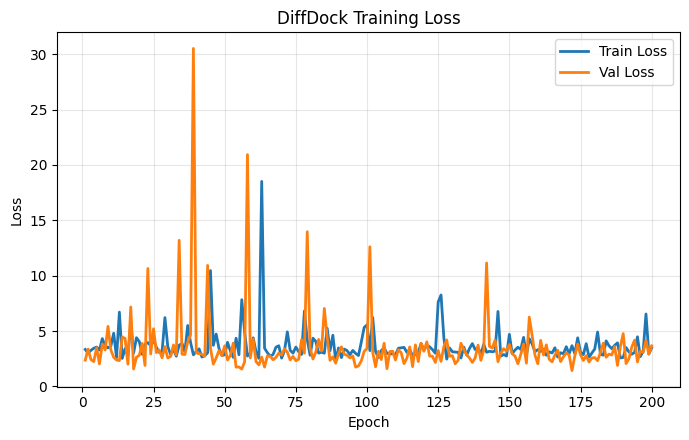

In [9]:
plot_loss_curves(train_loss_history, val_loss_history, title="DiffDock Training Loss")

## 总结

- 技术路线：保留 DiffDock 的全局 `translation / rotation / torsion` 分数预测。
- 教学骨架：统一为 `nn.Linear() + nn.ReLU()` 的简单 MLP。
- 训练输出：统一展示 train / val loss history。
- 主指标：`RMSD < 2A`。
- 训练损失未下降：`本notebook简化了分子的表征、模型的架构、训练的超参数，因此训练损失难以下降。完整的实现请参考 https://github.com/gcorso/DiffDock`